In [1]:
import torch

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

In [2]:
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)

In [3]:
train_input.shape, test_input.shape

((25000,), (25000,))

In [4]:
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)

In [5]:
train_input[0]

[1,
 73,
 89,
 81,
 25,
 60,
 2,
 6,
 20,
 141,
 17,
 14,
 31,
 127,
 12,
 60,
 28,
 2,
 2,
 66,
 45,
 6,
 20,
 15,
 497,
 8,
 79,
 17,
 491,
 8,
 112,
 6,
 2,
 20,
 17,
 2,
 2,
 4,
 436,
 20,
 9,
 2,
 6,
 2,
 7,
 493,
 2,
 6,
 185,
 250,
 24,
 55,
 2,
 5,
 23,
 350,
 7,
 15,
 82,
 24,
 15,
 2,
 66,
 10,
 10,
 45,
 2,
 15,
 4,
 20,
 2,
 8,
 30,
 17,
 2,
 5,
 2,
 17,
 2,
 190,
 4,
 20,
 9,
 43,
 32,
 99,
 2,
 18,
 15,
 8,
 157,
 46,
 17,
 2,
 4,
 2,
 5,
 2,
 9,
 32,
 2,
 5,
 2,
 267,
 17,
 73,
 17,
 2,
 36,
 26,
 400,
 43,
 2,
 83,
 4,
 2,
 247,
 74,
 83,
 4,
 250,
 2,
 82,
 4,
 96,
 4,
 250,
 2,
 8,
 32,
 4,
 2,
 9,
 184,
 2,
 13,
 384,
 48,
 14,
 16,
 147,
 2,
 59,
 62,
 69,
 2,
 12,
 46,
 50,
 9,
 53,
 2,
 74,
 2,
 11,
 14,
 31,
 151,
 10,
 10,
 4,
 20,
 9,
 2,
 364,
 352,
 5,
 45,
 6,
 2,
 2,
 33,
 269,
 8,
 2,
 142,
 2,
 5,
 2,
 17,
 73,
 17,
 204,
 5,
 2,
 19,
 55,
 2,
 2,
 92,
 66,
 104,
 14,
 20,
 93,
 76,
 2,
 151,
 33,
 4,
 58,
 12,
 188,
 2,
 151,
 12,
 215,
 69,
 224,
 142,


In [6]:
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [7]:
train_seq = torch.tensor(train_seq)
val_seq = torch.tensor(val_seq)

train_target = torch.tensor(train_target, dtype=torch.float32)
val_target = torch.tensor(val_target, dtype=torch.float32)

In [8]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_seq, train_target)
val_dataset = TensorDataset(val_seq, val_target)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

#### nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
- input_size: 입력 데이터의 피처(특징) 개수입니다.
- hidden_size: 은닉 상태(Hidden State)의 차원 크기입니다.
- num_layers: 쌓을 LSTM 레이어의 개수입니다 (기본값: 1).
- batch_first: True 설정 시 입력 텐서의 첫 차원을 배치 크기로 지정합니다 (기본값: False).
- bidirectional: True 설정 시 양방향 LSTM으로 동작합니다 (기본값: False)

In [9]:
import torch.nn as nn

class IMDBLstm(nn.Module):
    def __init__(self):
        super().__init__()
        # 입력된 단어 번호(상위 500개 단어)를 16차원의 밀집 벡터(의미를 담은 연속된 숫자들)로 변환, 텍스트를 컴퓨터가 이해할 수 있는 숫자로 확장하는 단계
        self.embedding = nn.Embedding(500,16)
        self.lstm = nn.LSTM(16,8, batch_first=True, num_layers=2, dropout=0.2)
        self.dense = nn.Linear(8,1) # LSTM의 출력(8차원)을 최종 예측값 1개(이진 분류용)로 변환하는 선형 레이어입니다.
        self.sigmoid = nn.Sigmoid() # 출력을 0과 1 사이의 확률값으로 변환

    # 데이터가 모델을 통과하는 흐름을 정의합니다.
    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        outputs = self.dense(hidden[-1])
        return self.sigmoid(outputs)

In [10]:
model = IMDBLstm()

In [11]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)
model.to(device) # GPU에서 실행 되도록 한다.

device = cuda


IMDBLstm(
  (embedding): Embedding(500, 16)
  (lstm): LSTM(16, 8, num_layers=2, batch_first=True, dropout=0.2)
  (dense): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [12]:
import torch.optim as optim

criterion = nn.BCELoss() # 이진분류: nn.BCELoss 또는 nn.BCEWithLogitsLoss
optimizer = optim.Adam(model.parameters())

In [13]:
train_hist = [] # 훈련 손실 저장
val_hist = [] # 검증 손실 저장
patience = 2 # 검증 손실이 향상될 때까지 에포크 횟수 설정
best_loss = -1 # 최상의 손실 저장
early_stopping_counter = 0 # 연속적으로 검증 손실이 향상되지 않은 에포크 횟수 저장

epochs = 100
for epoch in range(epochs): # 에포크 반복(학습)
    model.train() # 학습(훈련)
    train_loss = 0 # 손실값 초기화
    for inputs, targets in train_loader: # 1 epoch 실행
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad() # 이전에 계산된 기울기값 초기화하는 함수
        outputs = model(inputs) # 모델에 입력 데이터 전달 -> forward()메서드를 호출함
        loss = criterion(outputs.squeeze(), targets) # 손실값 계산, squeeze() : 차원 축소
        loss.backward() # 각 층의 모델 파라메터에 대한 기울기(그레디언트)를 계산
        optimizer.step() # 손실 파라메터 업데이트 
        train_loss += loss.item()
    
    model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
    val_loss = 0
    with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), targets)
            val_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},", f"훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_2lstm_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.6911, 검증 손실:0.6821
에포크:2, 훈련 손실:0.6463, 검증 손실:0.6152
에포크:3, 훈련 손실:0.5823, 검증 손실:0.5586
에포크:4, 훈련 손실:0.5421, 검증 손실:0.5573
에포크:5, 훈련 손실:0.5110, 검증 손실:0.5078
에포크:6, 훈련 손실:0.4888, 검증 손실:0.4939
에포크:7, 훈련 손실:0.4728, 검증 손실:0.4802
에포크:8, 훈련 손실:0.4594, 검증 손실:0.4893
에포크:9, 훈련 손실:0.4463, 검증 손실:0.4589
에포크:10, 훈련 손실:0.4385, 검증 손실:0.4696
에포크:11, 훈련 손실:0.4265, 검증 손실:0.4475
에포크:12, 훈련 손실:0.4220, 검증 손실:0.4449
에포크:13, 훈련 손실:0.4167, 검증 손실:0.4599
에포크:14, 훈련 손실:0.4106, 검증 손실:0.4433
에포크:15, 훈련 손실:0.4054, 검증 손실:0.4373
에포크:16, 훈련 손실:0.4007, 검증 손실:0.4411
에포크:17, 훈련 손실:0.3970, 검증 손실:0.4347
에포크:18, 훈련 손실:0.3931, 검증 손실:0.4356
에포크:19, 훈련 손실:0.3916, 검증 손실:0.4281
에포크:20, 훈련 손실:0.3866, 검증 손실:0.4296
에포크:21, 훈련 손실:0.3850, 검증 손실:0.4280
에포크:22, 훈련 손실:0.3840, 검증 손실:0.4354
에포크:23, 훈련 손실:0.3775, 검증 손실:0.4355
23번째 에포크에서 조기 종료되었습니다.


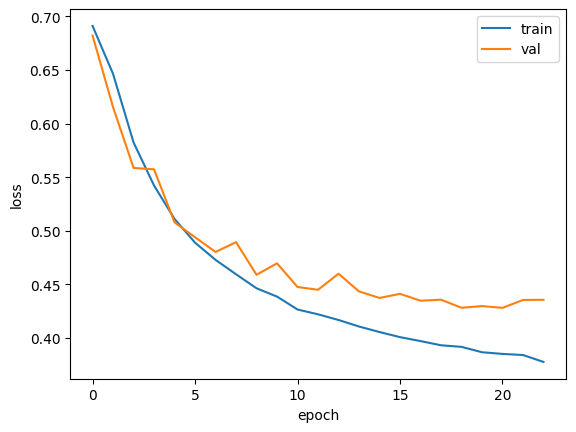

In [14]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [15]:
model.load_state_dict(torch.load('best_2lstm_model.pt', weights_only=True)) # 모델 로드

<All keys matched successfully>

In [16]:
test_seq = pad_sequences(test_input, maxlen=100)
test_seq = torch.tensor(test_seq)
test_target = torch.tensor(test_target, dtype=torch.float32)

In [17]:
test_dataset = TensorDataset(test_seq, test_target)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [18]:
model.eval() # PyTorch에서 모델을 검증(Validation) 및 추론(Inference) 모드로 전환하는 메서드
corrects = 0
with torch.no_grad(): # PyTorch에서 자동 미분(Autograd) 엔진을 비활성화, Gradient)를 계산하지 않음
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = outputs > 0.5
        corrects += (predicts.squeeze() == targets).sum().item() # 일치하는 데이터 카운트

accuracy = corrects / len(test_dataset) # 정확도 계산
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.8058
